In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
# === Imports ===
!pip install tensorly
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorly as tl

from scipy.stats import iqr
from tensorly.decomposition import randomised_parafac, tucker

# === Reproducibility ===
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

# === Paths ===
# In Colab this will usually point to mounted Drive or uploaded files
DATA_DIR = "Sparsify/data"
ATLAS_FILE = "elecs.npz"

# === Pipeline Parameters ===
RANK = 10
REQUIRED_T = 6000

# CP hyperparameters
N_INITS = 3
N_ITER = 200
N_OUTER = 10


# === Known Exclusions ===
EXCLUDE_PATIENTS = {
    "kh003": "signal saturation (hardware clipping ~70 uV)"
}

print("Notebook configuration loaded.")
print(f"Rank: {RANK} | Data dir: {DATA_DIR}")


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Notebook configuration loaded.
Rank: 10 | Data dir: Sparsify/data


In [2]:
# === Atlas loading cell ===
atlas_path = os.path.join(DATA_DIR, ATLAS_FILE)

elecs = np.load(atlas_path, allow_pickle=True)

print("Atlas loaded successfully")
print("electrodes:", elecs["pts"].shape[0])
print("clusters:", int(elecs["cluster"].max()) + 1)
print("patients:", len(np.unique(elecs["pts"][:, 0])))

Atlas loaded successfully
electrodes: 11716
clusters: 1000
patients: 98


In [3]:
# === Section 2: map one patient onto shared atlas clusters ===
def sparsify_patient(patient_id, elecs, data_path):
    """
    Build one patient's sparse cluster matrix and binary observation mask.

    Returns
    -------
    result : dict
        {
            "sparse": (T, C) float32 array or None,
            "mask": (T, C) float32 array or None,
            "obs_clusters": list[int],
            "n_channels": int or None,
            "regions": list[str],
            "error": str or None,
        }
    """
    if not os.path.exists(data_path):
        return {
            "sparse": None,
            "mask": None,
            "obs_clusters": [],
            "n_channels": None,
            "regions": [],
            "error": "file not found",
        }

    data = np.load(data_path)
    signal = data["data"]

    # Quality check: NaN / Inf
    n_nan = int(np.isnan(signal).sum())
    n_inf = int(np.isinf(signal).sum())
    if n_nan > 0 or n_inf > 0:
      return {
            "sparse": None,
            "mask": None,
            "obs_clusters": [],
            "n_channels": int(signal.shape[1]),
            "regions": [],
            "error": f"{n_nan} NaN + {n_inf} Inf values in signal",
        }

    # Keep supervisor variable semantics for safety
    pElecs = elecs["pts"][elecs["pts"][:, 0] == patient_id, 1]
    clusters = elecs["cluster"][elecs["pts"][:, 0] == patient_id]
    regions = elecs["pts"][elecs["pts"][:, 0] == patient_id, 2]

    n_clusters = int(elecs["cluster"].max()) + 1
    sparse = np.zeros((signal.shape[0], n_clusters), dtype=np.float32)
    mask = np.zeros_like(sparse, dtype=np.float32)

    obs_clusters = []
    obs_regions = []

    for ch_idx, ch_name in enumerate(data["chNames"].flatten()):
        if ch_name in pElecs:
            idx = np.where(pElecs == ch_name)
            sparse[:, clusters[idx]] = signal[:, ch_idx][:, None]
            mask[:, clusters[idx]] = 1.0

            obs_clusters.extend(clusters[idx].tolist())
            obs_regions.extend(regions[idx].tolist())

    return {
        "sparse": sparse,
        "mask": mask,
        "obs_clusters": sorted(set(obs_clusters)),
        "n_channels": len(data["chNames"].flatten()),
        "regions": sorted(set(obs_regions)),
        "error": None,
    }

In [4]:
# === Section 3: stack all valid patients into tensor ===
def build_tensor(data_dir, elecs, patient_subset=None, verbose=True):
    """
    Build cross-patient tensor X and binary mask W.

    Returns
    -------
    X : np.ndarray
        Shape (T, C, P)
    W : np.ndarray
        Binary observation mask, same shape as X
    pids : list[str]
        Included patient IDs in tensor order
    exclusion_report : pd.DataFrame
        Patient-level exclusion diagnostics
    """
    pts = np.unique(elecs["pts"][:, 0])
    if patient_subset is not None:
        pts = [p for p in pts if p in set(patient_subset)]

    slices, masks, pids = [], [], []
    excluded = []

    for patient_id in pts:
        if patient_id in EXCLUDE_PATIENTS:
            excluded.append({
                "id": patient_id,
                "reason": EXCLUDE_PATIENTS[patient_id],
                "T": None,
                    "channels": None,
                "active_clusters": None,
            })
            continue

        data_path = os.path.join(data_dir, f"{patient_id}.npz")
        result = sparsify_patient(patient_id, elecs, data_path)

        if result["sparse"] is None:
            excluded.append({
                "id": patient_id,
                "reason": result["error"],
                "T": None,
                "channels": result["n_channels"],
                "active_clusters": None,
            })
            continue

        sparse = result["sparse"]
        mask = result["mask"]
        T = sparse.shape[0]
        n_active = len(result["obs_clusters"])

        if T != REQUIRED_T:
            excluded.append({
                "id": patient_id,
                "reason": f"T={T} (required {REQUIRED_T})",
                "T": T,
                "channels": result["n_channels"],
                "active_clusters": n_active,
            })
            continue

        if n_active == 0:
            excluded.append({
                "id": patient_id,
                "reason": "no electrode matched atlas",
                "T": T,
                "channels": result["n_channels"],
                "active_clusters": 0,
            })
            continue

        slices.append(sparse)
        masks.append(mask)
        pids.append(patient_id)

        if verbose:
            print(
                f"Loaded {patient_id} | T={T} | "
                f"channels={result['n_channels']} | "
                f"clusters={n_active}"
            )

    if len(pids) == 0:
        raise ValueError("No patients passed inclusion criteria.")

    X = np.stack(slices, axis=2).astype(np.float32)
    W = np.stack(masks, axis=2).astype(np.float32)
    exclusion_report = pd.DataFrame(excluded)

    return X, W, pids, exclusion_report


In [5]:
X, W, pids, report = build_tensor(DATA_DIR, elecs)

print("tensor shape:", X.shape)
print("mask density:", W.mean())
print("included patients:", len(pids))
report.head()

Loaded kh002 | T=6000 | channels=130 | clusters=55
Loaded kh005 | T=6000 | channels=64 | clusters=17
Loaded kh006 | T=6000 | channels=128 | clusters=50
Loaded kh007 | T=6000 | channels=63 | clusters=33
Loaded kh008 | T=6000 | channels=110 | clusters=49
Loaded kh010 | T=6000 | channels=130 | clusters=60
Loaded kh011 | T=6000 | channels=128 | clusters=25
Loaded kh012 | T=6000 | channels=127 | clusters=29
Loaded kh013 | T=6000 | channels=125 | clusters=52
Loaded kh014 | T=6000 | channels=114 | clusters=50
Loaded kh015 | T=6000 | channels=130 | clusters=71
Loaded kh016 | T=6000 | channels=130 | clusters=67
Loaded kh017 | T=6000 | channels=47 | clusters=19
Loaded kh018 | T=6000 | channels=130 | clusters=68
Loaded kh019 | T=6000 | channels=130 | clusters=71
Loaded kh021 | T=6000 | channels=130 | clusters=63
Loaded kh022 | T=6000 | channels=125 | clusters=66
Loaded kh023 | T=6000 | channels=254 | clusters=84
Loaded kh024 | T=6000 | channels=130 | clusters=69
Loaded kh025 | T=6000 | channels=6

,id,reason,T,channels,active_clusters
0,kh001,12000 NaN + 0 Inf values in signal,NaN,107.0,NaN
1,kh003,signal saturation (hardware clipping ~70 uV),NaN,NaN,NaN
2,kh004,12000 NaN + 0 Inf values in signal,NaN,133.0,NaN
3,kh009,12000 NaN + 0 Inf values in signal,NaN,133.0,NaN
4,kh020,T=5155 (required 6000),5155.0,128.0,63.0


In [6]:
# === Section 4: robust per-patient per-cluster normalization ===
def normalise(X, W, clip_value=10.0, eps=1e-8):
    """
    Robust scaling using median and IQR on observed entries only.

    Parameters
    ----------
    X : np.ndarray
        Tensor of shape (T, C, P)
    W : np.ndarray
        Binary observation mask
    clip_value : float
        Clip normalized values to [-clip_value, clip_value]
    eps : float
        Numerical stability term for zero-IQR clusters
    """
    X_norm = X.copy().astype(np.float32)
    T, C, P = X.shape

    for p in range(P):
        for c in range(C):
            obs_mask = W[:, c, p] > 0
            if obs_mask.sum() <= 1:
                continue

            obs = X[:, c, p][obs_mask]
            med = np.median(obs)
            scale = iqr(obs) + eps

            normed = (X[:, c, p] - med) / scale
            normed = np.clip(normed, -clip_value, clip_value)

            # preserve sparsity semantics: only keep observed entries
            X_norm[:, c, p] = normed * obs_mask

    return X_norm

In [7]:
X_norm = normalise(X, W)

print("original range:", np.nanmin(X), np.nanmax(X))
print("normalized range:", np.nanmin(X_norm), np.nanmax(X_norm))
print("mask preserved:", np.all((X_norm == 0) | (W > 0)))

original range: -4.644946 115.91241
normalized range: -3.2423499 10.0
mask preserved: True


-0.003223385
0.34530222


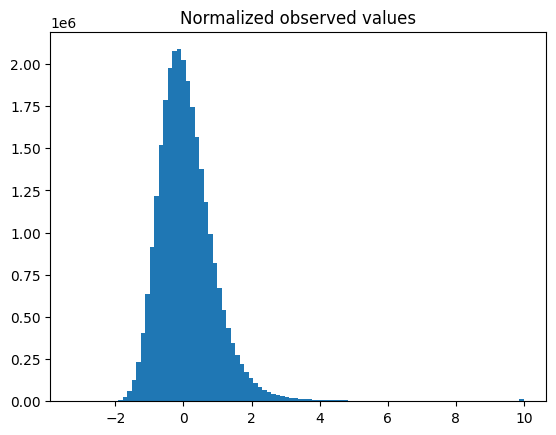

np.float64(0.0005016343352519008)

In [8]:
# Diagnostics
p = 0
print(np.mean(X[:, :, p][W[:, :, p] > 0]))
print(np.mean(X_norm[:, :, p][W[:, :, p] > 0]))

plt.hist(X_norm[W > 0].ravel(), bins=100)
plt.title("Normalized observed values")
plt.show()

# Clipping intensity
np.mean(np.abs(X_norm[W > 0]) >= 10)

In [11]:
# === Section 5A: CP decomposition with iterative imputation ===
def cp_decompose(
    X,
    W,
    rank,
    n_iter=200,
    tol=1e-5,
    n_inits=3,
    n_outer=10,
    random_state=0,
    sample_ratio=0.3,
):
    """
    CP decomposition with iterative missing-value imputation.

    Returns
    -------
    best_factors : list[np.ndarray]
    best_loss : float
    loss_history : list[list[float]]
        Loss trajectory for each initialization
    """
    best_factors, best_loss = None, np.inf
    T = X.shape[0]
    n_samples = max(10, int(T * sample_ratio))
    loss_history = []

    for init_idx in range(n_inits):
        X_filled = X.copy()
        X_filled[W == 0] = 0

        prev_loss = np.inf
        cp = None
        init_losses = []

        print(f"CP init {init_idx+1}/{n_inits}")

        for outer in range(n_outer):
            cp = randomised_parafac(
                tl.tensor(X_filled),
                rank=rank,
                n_samples=n_samples,
                n_iter_max=max(10, n_iter // n_outer),
                init="svd" if (outer == 0 and init_idx == 0) else "random",
                random_state=random_state + init_idx + outer,
            )

            X_hat = np.array(tl.cp_to_tensor(cp))
            X_filled = X.copy()
            X_filled[W == 0] = X_hat[W == 0]

            loss = float(np.sum((W > 0) * (X - X_hat) ** 2))
            init_losses.append(loss)
            print(f"  outer {outer+1}/{n_outer} | loss={loss:.2f}")

            rel_change = abs(prev_loss - loss) / (prev_loss + 1e-12)
            if rel_change < tol:
                print(f"  converged at outer={outer+1}")

            rel_change = abs(prev_loss - loss) / (prev_loss + 1e-12)
            if rel_change < tol:
                print(f"  converged at outer={outer+1}")
                break

            prev_loss = loss

        loss_history.append(init_losses)

        if loss < best_loss:
            best_loss = loss
            best_factors = [np.array(f) for f in cp.factors]

    return best_factors, best_loss, loss_history

In [ ]:
# Run CP
factors_cp, loss_cp, loss_history_cp = cp_decompose(
    X_norm,
    W,
    rank=RANK,
    n_inits=N_INITS,
    n_iter=N_ITER,
    n_outer=N_OUTER,
    random_state=RANDOM_STATE,
)

CP init 1/3


In [14]:
X_norm = X_norm.astype(np.float32)
W = W.astype(bool)

X_sub = X_norm[:, :, :5]
W_sub = W[:, :, :5]
ranks = (30, 20, 3)

In [12]:
# === Section 5B: Tucker decomposition ===
# Not masked Tucker
def tucker_decompose(X, W, ranks):
    """Simple Tucker baseline using zero-filled missing entries."""
    X_filled = X.copy()
    X_filled[W == 0] = 0

    core, factors = tucker(
        tl.tensor(X_filled),
        rank=ranks,
        init="svd",
    )

    return core, [np.array(f) for f in factors]

In [13]:
# Run Tucker
ranks = (RANK, RANK, RANK)
core_tucker, factors_tucker = tucker_decompose(
    X_norm,
    W,
    ranks=ranks,
)

C:\Users\Lenovo\PycharmProjects\Plotting\.venv\Lib\site-packages\numpy\linalg\_linalg.py:1798: RuntimeWarning: overflow encountered in cast
  s = s.astype(_realType(result_t), copy=False)


MemoryError: Unable to allocate 3.93 GiB for an array with shape (1000, 528000) and data type float64

In [15]:
# Masked Tucker
def tucker_decompose_masked(X, W, ranks, n_iter_max=100, tol=1e-4):
    """
    Tucker decomposition with native TensorLy masking.
    W should be 1 for observed entries, 0 for missing.
    """
    mask = W.astype(bool)

    core, factors = tucker(
        tl.tensor(X),
        rank=ranks,
        init="svd",
        mask=mask,
        n_iter_max=n_iter_max,
        tol=tol,
    )

    return core, [np.array(f) for f in factors]

In [21]:
def create_validation_mask(W, frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    obs_idx = np.argwhere(W)

    n_val = int(len(obs_idx) * frac)
    chosen = rng.choice(len(obs_idx), n_val, replace=False)
    val_idx = obs_idx[chosen]

    W_train = W.copy()
    W_val = np.zeros_like(W)

    for t, c, p in val_idx:
        W_train[t, c, p] = False
        W_val[t, c, p] = True

    return W_train, W_val

In [22]:
def masked_rmse(X, W_eval, core, factors):
    X_hat = np.array(tl.tucker_to_tensor((core, factors)))
    err = (X - X_hat)[W_eval]
    return np.sqrt(np.mean(err**2))

In [23]:
W_train, W_val = create_validation_mask(W_sub)

core_masked_tucker, factors_masked_tucker = tucker_decompose_masked(
    X_sub,
    W_sub,
    ranks=ranks,
)
rmse = masked_rmse(X_sub, W_val, core_masked_tucker, factors_masked_tucker)

In [24]:
print(rmse)

0.5194421766308581


In [25]:
def fit_score(X, W, core, factors):
    X_hat = np.array(tl.tucker_to_tensor((core, factors)))
    obs = W
    sse = np.sum((X[obs] - X_hat[obs])**2)
    sst = np.sum(X[obs]**2)
    return 1 - sse/sst

print(fit_score(X_sub, W_sub, core_masked_tucker, factors_masked_tucker))

0.7727493843422518


In [ ]:
for i, losses in enumerate(loss_history):
    plt.plot(losses, label=f"init {i+1}")
plt.legend()
plt.title("CP loss trajectory")
plt.xlabel("outer iteration")
plt.ylabel("observed-entry SSE")
plt.show()

In [ ]:
# === Section 6A: textual component summaries ===
def summarize_components(factors, pids, elecs, top_k=5, label="CP"):
    """
    Print a compact summary of temporal, spatial, and patient loadings.
    """
    A, B, C = factors
    centroids = elecs["centroids"]
    R = A.shape[1]

    print(f"=== {label} Component Summary ===")

    for r in range(R):
        spatial = B[:, r]
        temporal = A[:, r]
        patient = C[:, r]

        top_clusters = np.argsort(np.abs(spatial))[-top_k:][::-1]
        peak_t = int(np.argmax(np.abs(temporal)))
        top_patients = np.argsort(np.abs(patient))[-3:][::-1]

        print(f"--- Component {r+1} ---")
        print(f"Peak time sample: {peak_t}")
        print("Top clusters:")

        for idx in top_clusters:
            mni = centroids[idx]
            print(
                f"  cluster {idx:4d} | "
                f"MNI [{mni[0]:+.1f}, {mni[1]:+.1f}, {mni[2]:+.1f}] | "
                f"loading={spatial[idx]:.3f}"
            )

        print("Top patients:", [pids[i] for i in top_patients])

In [ ]:
# === Section 6B: temporal factor visualization ===
def plot_temporal_factors(factors, max_components=None):
    A = factors[0]
    R = A.shape[1]
    n_plot = R if max_components is None else min(R, max_components)

    plt.figure(figsize=(14, 4))
    for r in range(n_plot):
        plt.plot(A[:, r], label=f"comp {r+1}")

    plt.title("Temporal Factors")
    plt.xlabel("Time")
    plt.ylabel("Loading")
    plt.legend()
    plt.show()

In [ ]:
# === Section 6C: patient-component heatmap ===
def plot_patient_loadings(factors, pids):
    C = factors[2]

    plt.figure(figsize=(10, 6))
    plt.imshow(C, aspect="auto")
    plt.colorbar(label="loading")
    plt.yticks(range(len(pids)), pids)
    plt.xlabel("Component")
    plt.ylabel("Patient")
    plt.title("Patient Loadings")
    plt.show()

In [ ]:
# Summarize CP
summarize_components(factors_cp, pids, elecs, label="CP")
plot_temporal_factors(factors_cp)
plot_patient_loadings(factors_cp, pids)

In [ ]:
# Summarize Tucker
summarize_components(factors_tucker, pids, elecs, label="Tucker")
plot_temporal_factors(factors_tucker)
plot_patient_loadings(factors_tucker, pids)